# Stored restriction maps visualisations

## 1. Import an Functions

In [1]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from scipy import stats
from tkinter import font

In [2]:
def fbc(L):
    l=L.shape[0]
    B=L.copy()
    for i in range(l):
        B[i,i]=np.sum(np.abs(L[i,:]))-np.abs(L[i,i])

    F=L-B
    return B , F

## 2. Data Manipulation: Load Laplacian and compute curvatures 

In [18]:
stalk_dim = 1
hidden_channels = 16
dataset = "texas"
layers = 2
epochs = 500

# store node features if needed
#with open(f"../datasets/{dataset}/raw/out1_node_feature_label.txt", "r") as f:
    # for line in f:
    #     print(line.strip())
    # df_node_feature = pd.read_csv(f"../datasets/{dataset}/raw/out1_node_feature_label.txt", sep="\t")

MAPS, LAPLACIANS = [], []
for layer in range(layers):
    map_path = f"../results/maps/{dataset}/stalk_dim-{stalk_dim}/{layers}-layers/{hidden_channels}-hidden/{epochs}-epochs/DiagSheaf_{dataset}_layer{layer}_fold7_seed43.pt"
    lap_path = f"../results/laplacians/{dataset}/stalk_dim-{stalk_dim}/{layers}-layers/{hidden_channels}-hidden/{epochs}-epochs/DiagSheaf_{dataset}_layer{layer}_fold7_seed43.pt"
    MAPS.append(torch.load(map_path))
    LAPLACIANS.append(torch.load(lap_path))

DF = []
for maps in MAPS:
    df = pd.DataFrame(maps.cpu().tolist(), columns=["source", "target", "map_value"])
    df[["source", "target"]] = df[["source", "target"]].astype(int)
    df.sort_values(by=["source", "target"], ascending=[True, True], inplace=True)
    DF.append(df)   

DF_Lap = []
for laplacian in LAPLACIANS:
    df = pd.DataFrame(laplacian.cpu().tolist())
    DF_Lap.append(df)

C:\Users\Utente\AppData\Local\Temp\ipykernel_24600\1665079889.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  MAPS.append(torch.load(map_path))
C:\Users\Utente\AppData\

In [19]:
L0_LIST = []
L1_LIST = []
ev0_list = []
e0_list = []
f0_list = []

for df in DF_Lap:

    df = df.transpose().copy()
    # display(df)
    df.rename(columns={0: "source", 1: "target", 2: "value"}, inplace=True)
    df_new = df.pivot(index="source", columns="target", values="value").fillna(0)
    L0 = df_new.to_numpy()
    #display(L0)
    
    B0, F0 = fbc(L0)
    L0_LIST.append(L0)
    e0,ev0 = np.linalg.eigh(L0)
    ev0_list.append(ev0)
    e0_list.append(e0)
    f0_list.append(np.diag(F0))
    

In [20]:
B_list = []

for df in DF:

    df = df.copy()
    df[["source", "target"]] = df[["source", "target"]].astype(int)

    # signed value
    df["signed_map"] = np.where(df["target"] < df["source"], df["map_value"], -df["map_value"])

    # canonical undirected edge label
    df["edge"] = df.apply(lambda r: (min(r["source"], r["target"]), max(r["source"], r["target"])),axis=1)

    # build node-by-edge matrix
    nodes = sorted(set(df["source"]).union(df["target"]))
    edges = sorted(df["edge"].unique())

    B = df.pivot(index="source", columns="edge", values="signed_map")
    B = B.reindex(index=nodes, columns=edges, fill_value=0)

    B.fillna(0, inplace=True)
    B_np = B.to_numpy(dtype=float)

    B_list.append(B)

EDGE_LIST = []
NODE_LIST = []

for B in B_list:
    EDGE_LIST.append(list(B.columns))
    NODE_LIST.append(B.index.tolist())

In [21]:
G = nx.Graph()
G.add_nodes_from(B.index)
G.add_edges_from(list(B.columns))
B_top = nx.incidence_matrix(G, oriented=True).todense()
L0_top_un = nx.laplacian_matrix(G).todense()
print(np.all(L0_top_un == B_top @ B_top.T))
d0_top = np.diag(L0_top_un)+1 # add identity to avoid division by zero
D0_inv_top = np.diag(1.0 / d0_top)
D0_inv_sqrt_top = np.diag(1.0 / np.sqrt(d0_top))
L0_top = D0_inv_sqrt_top @ L0_top_un @ D0_inv_sqrt_top
B0_top, F0_top = fbc(L0_top)
f0_top =np.diag(F0_top)
e0_top , ev0_top = np.linalg.eigh(L0_top)

True


## 3. Visualizations: Plot of curvatures, and then spectral quantities 

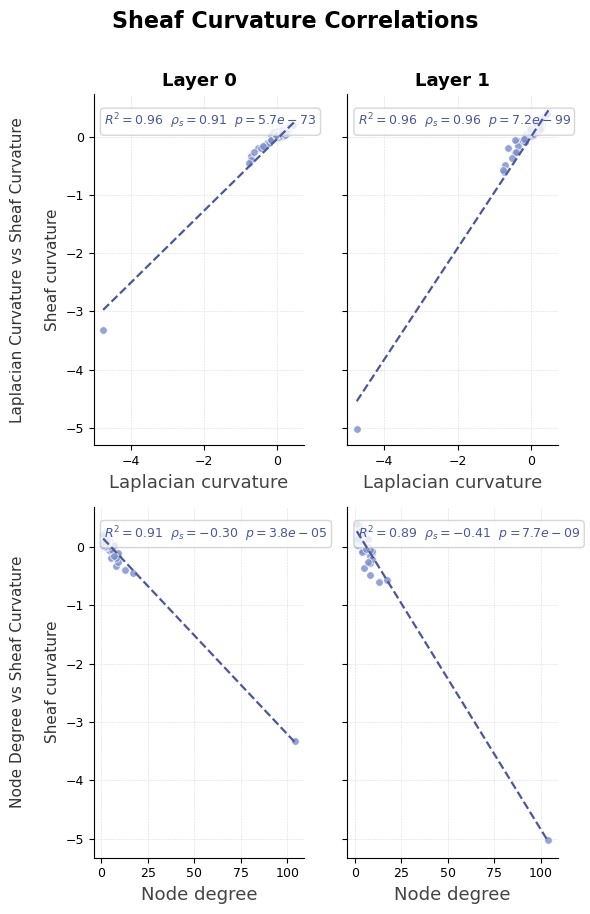

In [22]:
fig, axes = plt.subplots(nrows=2, ncols=layers, figsize=(3 * layers, 9), sharey='row')

scatter_color = "#7B8EC8"
line_color    = "#4A5899"

# --- Data for each row, clearly named ---
laplacian_curvature = f0_top
node_degrees        = [len(G.edges(node)) for node in G.nodes()]

row_xlabels = ["Laplacian curvature", "Node degree"]
row_xdata   = [laplacian_curvature,   node_degrees]
row_titles  = ["Laplacian Curvature vs Sheaf Curvature",
               "Node Degree vs Sheaf Curvature"]

for row in range(2):
    x = row_xdata[row]

    for layer in range(layers):
        ax = axes[row, layer]
        y  = f0_list[layer]

        # Scatter
        ax.scatter(x, y, color=scatter_color, alpha=0.8, s=30,
                   edgecolors="white", linewidths=0.6, zorder=3)

        # Regression line
        slope, intercept, r_value, _, _ = stats.linregress(x, y)
        x_range = np.linspace(min(x), max(x), 200)
        ax.plot(x_range, slope * x_range + intercept,
                color=line_color, linewidth=1.6, linestyle="--", zorder=4)

        # Stats annotation (top-left)
        spearman_r, spearman_p = stats.spearmanr(x, y)
        stats_text = f"$R^2={r_value**2:.2f}$  $\\rho_s={spearman_r:.2f}$  $p={spearman_p:.1e}$"
        ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
                fontsize=9, color=line_color, va="top",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                          edgecolor="#cccccc", alpha=0.8))

        # Axes labels — only where needed to avoid repetition
        ax.set_xlabel(row_xlabels[row], fontsize=13, color="#444444")
        if layer == 0:
            ax.set_ylabel("Sheaf curvature", fontsize=13, color="#444444")
        if row == 0:
            ax.set_title(f"Layer {layer}", fontsize=13, fontweight="semibold")

        # Light styling
        ax.grid(True, linestyle="--", linewidth=0.4, color="gainsboro")
        ax.spines[["top", "right"]].set_visible(False)
        ax.tick_params(labelsize=9)

    # Row title on the far left
    axes[row, 0].set_ylabel(f"{row_titles[row]}\n\nSheaf curvature",
                             fontsize=11, color="#333333")

fig.suptitle("Sheaf Curvature Correlations", fontsize=16, fontweight="semibold", y=1.01)
plt.tight_layout()
plt.show()

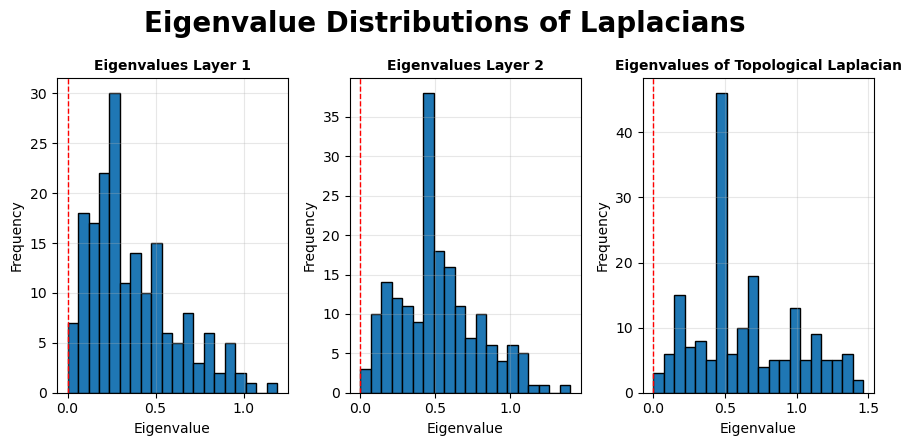

In [23]:
# for each layer, plot the distribution of the eigenvalues of the Laplacian, and then for the final
# plot please plot the distribution of the eigenvalues of the "topolotical" Laplacian (the one obtained from the incidence matrix)
f, axes = plt.subplots(nrows=1, ncols=layers+1, figsize=(3*(layers+1), 4.5))
for layer in range(layers):
    ax = axes[layer]
    e0 = e0_list[layer]
    ax.hist(e0, bins=20, edgecolor="black")
    ax.axvline(0, color="red", linestyle="--", linewidth=1)
    ax.set_title(f"Eigenvalues Layer {layer+1}", fontsize=10, fontweight="bold")
    ax.set_xlabel("Eigenvalue")
    ax.set_ylabel("Frequency")
    ax.grid(alpha=0.3)
# Final plot for the topological Laplacian
ax = axes[layers]
ax.hist(e0_top, bins=20, edgecolor="black")
ax.axvline(0, color="red", linestyle="--", linewidth=1)
ax.set_title("Eigenvalues of Topological Laplacian", fontsize=10, fontweight="bold")
ax.set_xlabel("Eigenvalue")
ax.set_ylabel("Frequency")
ax.grid(alpha=0.3)
f.suptitle("Eigenvalue Distributions of Laplacians", fontsize=20, fontweight="bold")
f.tight_layout()

## 4. Plotting of the Graphs

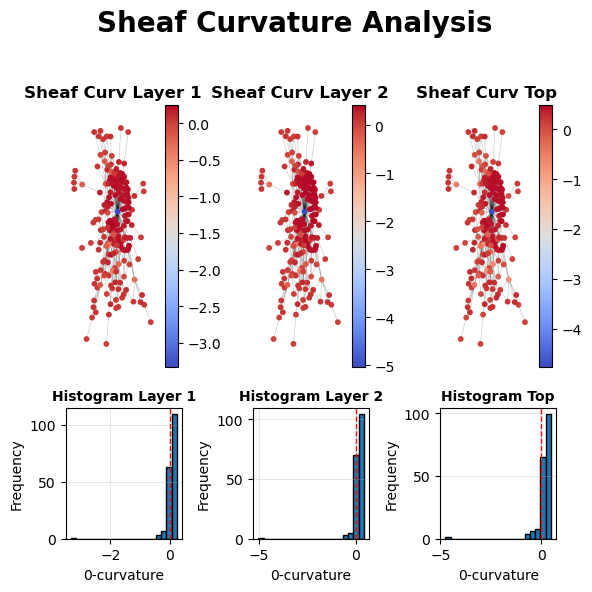

In [24]:
pos_use = nx.spring_layout(G, seed=42)
cmap    = plt.cm.coolwarm

fig, ax = plt.subplots(2, layers + 1, figsize=(2*(layers + 1), 6),
                       gridspec_kw={"height_ratios": [3, 1.5]})

# ---------- One column per layer ----------
for layer in range(layers):
    curvatures = np.asarray(f0_list[layer])
    norm       = plt.Normalize(vmin=curvatures.min(), vmax=curvatures.max())

    nx.draw_networkx_nodes(G, pos_use, ax=ax[0, layer], node_size=10, node_color=cmap(norm(curvatures)))
    nx.draw_networkx_edges(G, pos_use, ax=ax[0, layer], width=0.5, alpha=0.2)
    plt.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm), ax=ax[0, layer])
    ax[0, layer].set_title(f"Sheaf Curv Layer {layer+1}", fontweight="bold", fontsize=12)
    ax[0, layer].axis("off")

    ax[1, layer].hist(curvatures, bins=20, edgecolor="black")
    ax[1, layer].axvline(0, color="red", linestyle="--", linewidth=1)
    ax[1, layer].set_title(f"Histogram Layer {layer+1}", fontsize=10, fontweight="bold")
    ax[1, layer].set_xlabel("0-curvature")
    ax[1, layer].set_ylabel("Frequency")
    ax[1, layer].grid(alpha=0.3)

# ---------- Last column: f0_top ----------
f0_top_arr = np.asarray(f0_top)
norm       = plt.Normalize(vmin=f0_top_arr.min(), vmax=f0_top_arr.max())

nx.draw_networkx_nodes(G, pos_use, ax=ax[0, layers], node_size=10, node_color=cmap(norm(f0_top_arr)))
nx.draw_networkx_edges(G, pos_use, ax=ax[0, layers], width=0.5, alpha=0.2)
plt.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm), ax=ax[0, layers])
ax[0, layers].set_title("Sheaf Curv Top", fontweight="bold", fontsize=12)
ax[0, layers].axis("off")

ax[1, layers].hist(f0_top_arr, bins=20, edgecolor="black")
ax[1, layers].axvline(0, color="red", linestyle="--", linewidth=1)
ax[1, layers].set_title("Histogram Top", fontsize=10, fontweight="bold")
ax[1, layers].set_xlabel("0-curvature")
ax[1, layers].set_ylabel("Frequency")
ax[1, layers].grid(alpha=0.3)

fig.suptitle("Sheaf Curvature Analysis", fontsize=20, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

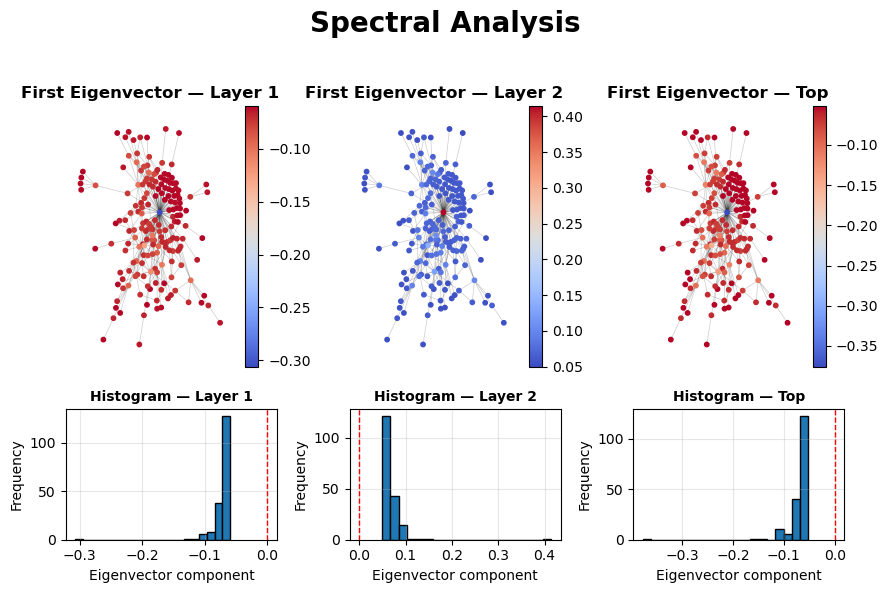

In [25]:
fig, ax = plt.subplots(2, layers + 1, figsize=(3 * (layers + 1), 6),
                       gridspec_kw={"height_ratios": [3, 1.5]})

# ---------- One column per layer ----------
for layer in range(layers):
    eig00 = np.asarray(ev0_list[layer][:, 0])
    norm  = plt.Normalize(vmin=eig00.min(), vmax=eig00.max())

    nx.draw_networkx_nodes(G, pos_use, ax=ax[0, layer], node_size=10, node_color=cmap(norm(eig00)))
    nx.draw_networkx_edges(G, pos_use, ax=ax[0, layer], width=0.5, alpha=0.2)
    plt.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm), ax=ax[0, layer])
    ax[0, layer].set_title(f"First Eigenvector — Layer {layer+1}", fontweight="bold", fontsize=12)
    ax[0, layer].axis("off")

    ax[1, layer].hist(eig00, bins=20, edgecolor="black")
    ax[1, layer].axvline(0, color="red", linestyle="--", linewidth=1)
    ax[1, layer].set_title(f"Histogram — Layer {layer+1}", fontsize=10, fontweight="bold")
    ax[1, layer].set_xlabel("Eigenvector component")
    ax[1, layer].set_ylabel("Frequency")
    ax[1, layer].grid(alpha=0.3)

# ---------- Last column: ev0_top ----------
eig_top = np.asarray(ev0_top[:, 0])
norm    = plt.Normalize(vmin=eig_top.min(), vmax=eig_top.max())

nx.draw_networkx_nodes(G, pos_use, ax=ax[0, layers], node_size=10, node_color=cmap(norm(eig_top)))
nx.draw_networkx_edges(G, pos_use, ax=ax[0, layers], width=0.5, alpha=0.2)
plt.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm), ax=ax[0, layers])
ax[0, layers].set_title("First Eigenvector — Top", fontweight="bold", fontsize=12)
ax[0, layers].axis("off")

ax[1, layers].hist(eig_top, bins=20, edgecolor="black")
ax[1, layers].axvline(0, color="red", linestyle="--", linewidth=1)
ax[1, layers].set_title("Histogram — Top", fontsize=10, fontweight="bold")
ax[1, layers].set_xlabel("Eigenvector component")
ax[1, layers].set_ylabel("Frequency")
ax[1, layers].grid(alpha=0.3)

fig.suptitle("Spectral Analysis", fontsize=20, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()